    This notebook contains the tutorial for the module GeneralUtils. The function used in this modules are of general use cases and can be used in different situations, other than the present work.

In [1]:
# Libraries required
using JLD2, FileIO
# using HDF5, JLD
using JLD
using NPZ
using PyCall
using PyPlot
using Dates
using Crayons

In [3]:
"""
    check_rel_tol(oldList, newList; tol=1e-5)

Check whether two vectors have converged within a relative tolerance.

Arguments:
- `oldList`: vector of previous values
- `newList`: vector of updated values
- `tol`: relative tolerance (default `1e-5`)

Returns:
- `true` if all elementwise relative differences are ≤ `tol`, otherwise `false`

Notes:
- Uses `max(abs(new), abs(old), eps)` in the denominator to be safe when values are near zero.
"""
@inline function check_rel_tol(oldList::AbstractVector, newList::AbstractVector; tol::Real=1e-5)
    @assert length(oldList) == length(newList) "Lists must be of the same length"

    Teps = eps(float(real(eltype(newList))))
    @inbounds for i in eachindex(oldList, newList)
        den = max(abs(newList[i]), abs(oldList[i]), Teps)
        if abs(newList[i] - oldList[i]) / den > tol
            return false
        end
    end
    return true
end

"""
    check_tol(oldList, newList; rtol=1e-5, atol=1e-10)

Check whether two vectors have converged within absolute + relative tolerances.

Arguments:
- `oldList`: vector of previous values
- `newList`: vector of updated values
- `rtol`: relative tolerance (default `1e-5`)
- `atol`: absolute tolerance (default `1e-10`)

Returns:
- `true` if all elements satisfy `abs(new-old) ≤ atol + rtol*max(abs(new),abs(old))`, otherwise `false`
"""
@inline function check_tol(oldList::AbstractVector, newList::AbstractVector; rtol::Real=1e-5, atol::Real=1e-10)
    @assert length(oldList) == length(newList) "Lists must be of the same length"

    @inbounds for i in eachindex(oldList, newList)
        if abs(newList[i] - oldList[i]) > (atol + rtol * max(abs(newList[i]), abs(oldList[i])))
            return false
        end
    end
    return true
end


check_tol

In [4]:
# Example 1
old = [1.0, 2.0, 3.0]
new = [1.0 + 1e-7, 2.0 - 1e-7, 3.0 + 2e-7]

@show check_rel_tol(old, new; tol=1e-5)

# Example 2
old = [1.0, 2.0, 3.0]
new = [1.0, 2.0, 3.0001]   # relative diff ≈ 3.3e-5

@show check_rel_tol(old, new; tol=1e-5)

# Example 2
old = [1.0 + 1.0im, 2.0 - 1.0im]
new = [1.0 + 1.0im + 1e-7,
       2.0 - 1.0im - 1e-7]

@show check_rel_tol(old, new; tol=1e-5)

check_rel_tol(old, new; tol = 1.0e-5) = true
check_rel_tol(old, new; tol = 1.0e-5) = false
check_rel_tol(old, new; tol = 1.0e-5) = true


true

In [5]:
"""
    save_file(object, fileName; key="data")

Save an object to disk in one of the supported file formats:
`jld`, `jld2`, `npz`, or `pkl`.

Arguments:
- `object`: data object to be saved
- `fileName`: output file name (extension determines format)
- `key`: dataset name used for `jld`/`jld2` files (default `"data"`)

Returns:
- `nothing`
"""
function save_file(object, fileName; key="data")
    ext = lowercase(splitext(fileName)[2])  # ".jld", ".jld2", ".npz", ".pkl"

    if ext == ".jld"
        JLD.save(fileName, key, object)

    elseif ext == ".jld2"
        JLD2.save(fileName, key, object)

    elseif ext == ".npz"
        npzwrite(fileName, object)

    elseif ext == ".pkl"
        open(fileName, "wb") do f
            pickle.dump(object, f, protocol=pickle.HIGHEST_PROTOCOL)
        end

    else
        throw(ArgumentError("Unsupported file format: $ext. Use jld, jld2, npz, or pkl."))
    end

    return nothing
end


"""
    load_file(fileName; key="data")

Load and return data from a supported file format.

Arguments:
- `fileName`: input file name (extension determines format)
- `key`: dataset name used for `jld`/`jld2` files (default `"data"`)

Returns:
- the loaded object
"""
function load_file(fileName; key="data")
    ext = lowercase(splitext(fileName)[2])

    if ext == ".npz"
        return npzread(fileName)

    elseif ext == ".jld"
        return JLD.load(fileName, key)

    elseif ext == ".jld2"
        return JLD2.load(fileName, key)

    elseif ext == ".pkl"
        return open(fileName, "rb") do f
            pickle.load(f)
        end

    else
        throw(ArgumentError("Unsupported file format: $ext. Use npz, jld, jld2, or pkl."))
    end
end

load_file

In [6]:
# Example object to save
data = Dict(
    "U" => 4.0,
    "mu" => -1.25,
    "Delta" => [0.12, 0.15, 0.11, 0.14]
)

fileName = "output-files/example_data.jld2"
save_file(data, fileName)

In [7]:
loadedData = load_file(fileName)

Dict{String, Any} with 3 entries:
  "U"     => 4.0
  "Delta" => [0.12, 0.15, 0.11, 0.14]
  "mu"    => -1.25

In [8]:
"""
    show_all(obj)

Display `obj` to standard output without truncation.
"""
function show_all(obj)
    show(stdout, MIME("text/plain"), obj)
    return nothing
end

show_all

In [9]:
testObj = reshape(1:400, 20, 20)  # truncated output

20×20 reshape(::UnitRange{Int64}, 20, 20) with eltype Int64:
  1  21  41  61   81  101  121  141  …  261  281  301  321  341  361  381
  2  22  42  62   82  102  122  142     262  282  302  322  342  362  382
  3  23  43  63   83  103  123  143     263  283  303  323  343  363  383
  4  24  44  64   84  104  124  144     264  284  304  324  344  364  384
  5  25  45  65   85  105  125  145     265  285  305  325  345  365  385
  6  26  46  66   86  106  126  146  …  266  286  306  326  346  366  386
  7  27  47  67   87  107  127  147     267  287  307  327  347  367  387
  8  28  48  68   88  108  128  148     268  288  308  328  348  368  388
  9  29  49  69   89  109  129  149     269  289  309  329  349  369  389
 10  30  50  70   90  110  130  150     270  290  310  330  350  370  390
 11  31  51  71   91  111  131  151  …  271  291  311  331  351  371  391
 12  32  52  72   92  112  132  152     272  292  312  332  352  372  392
 13  33  53  73   93  113  133  153     273  293  3

In [10]:
show_all(testObj)

20×20 reshape(::UnitRange{Int64}, 20, 20) with eltype Int64:
  1  21  41  61   81  101  121  141  161  181  201  221  241  261  281  301  321  341  361  381
  2  22  42  62   82  102  122  142  162  182  202  222  242  262  282  302  322  342  362  382
  3  23  43  63   83  103  123  143  163  183  203  223  243  263  283  303  323  343  363  383
  4  24  44  64   84  104  124  144  164  184  204  224  244  264  284  304  324  344  364  384
  5  25  45  65   85  105  125  145  165  185  205  225  245  265  285  305  325  345  365  385
  6  26  46  66   86  106  126  146  166  186  206  226  246  266  286  306  326  346  366  386
  7  27  47  67   87  107  127  147  167  187  207  227  247  267  287  307  327  347  367  387
  8  28  48  68   88  108  128  148  168  188  208  228  248  268  288  308  328  348  368  388
  9  29  49  69   89  109  129  149  169  189  209  229  249  269  289  309  329  349  369  389
 10  30  50  70   90  110  130  150  170  190  210  230  250  270  290  310

In [11]:
"""
    show_matrix(mat)

Display a matrix as a grayscale image with no interpolation and a colorbar.
"""
function show_matrix(mat)
    fig, ax = subplots()
    im = ax.imshow(mat, cmap="gray", interpolation="none")
    fig.colorbar(im, ax=ax)
    return nothing
end

show_matrix

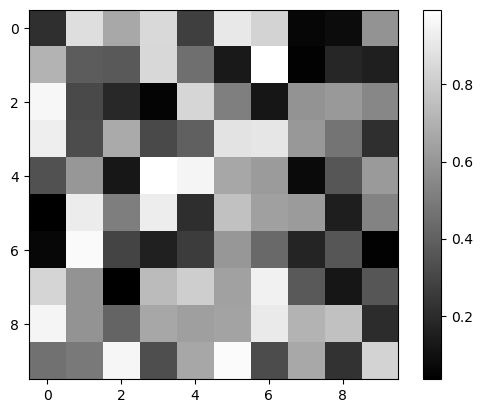

In [12]:
mat = rand(10, 10)
show_matrix(mat)